<a href="https://colab.research.google.com/github/Shubz15/Machine-Learning-Training/blob/main/Exp_9/Experiment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [2]:
data = pd.read_csv("iris.data.csv", header=None)
data.columns = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species']
print("First 5 rows:")
print(data.head())
print("\nColumn Names:")
print(data.columns)
print("\nDataset Shape:")
print(data.shape)


First 5 rows:
   SepalLength  SepalWidth  PetalLength  PetalWidth       Species
0          5.1         3.5          1.4         0.2   Iris-setosa
1          4.9         3.0          1.4         0.2   Iris-setosa
2          4.7         3.2          1.3         0.2   Iris-setosa
3          4.6         3.1          1.5         0.2   Iris-setosa
4          5.0         3.6          1.4         0.2   Iris-setosa

Column Names:
Index(['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species'], dtype='object')

Dataset Shape:
(150, 5)


In [3]:
X = data.iloc[:, :-1]
print("\nSelected Features:")
print(X.head())



Selected Features:
   SepalLength  SepalWidth  PetalLength  PetalWidth
0          5.1         3.5          1.4         0.2
1          4.9         3.0          1.4         0.2
2          4.7         3.2          1.3         0.2
3          4.6         3.1          1.5         0.2
4          5.0         3.6          1.4         0.2


In [4]:
wcss = []
for i in range(1, 11):
 kmeans_temp = KMeans(n_clusters=i, random_state=42)
 kmeans_temp.fit(X)
 wcss.append(kmeans_temp.inertia_)
print("\nWCSS Values:")
print(wcss)



WCSS Values:
[680.8243999999996, 152.36870647733915, 78.94506582597728, 57.44028021295475, 46.535582051282034, 39.251830892636775, 35.04275995246584, 30.217021122152712, 28.7564561965812, 28.424891802641817]


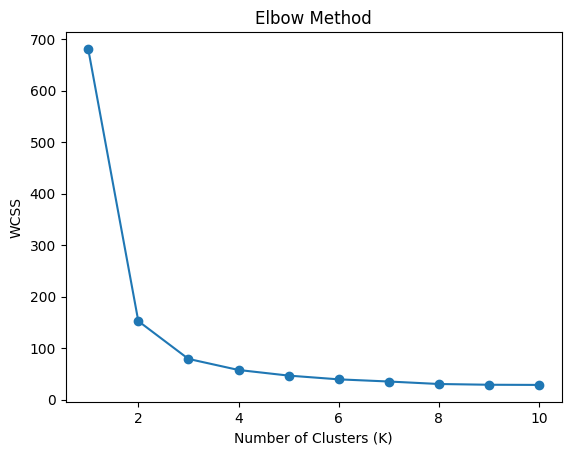

In [5]:
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)
print("\nK-Means Model Trained Successfully")



K-Means Model Trained Successfully


In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

In [8]:
data['Cluster'] = clusters
print("\nDataset with Cluster Labels:")
print(data.head())


Dataset with Cluster Labels:
   SepalLength  SepalWidth  PetalLength  PetalWidth       Species  Cluster
0          5.1         3.5          1.4         0.2   Iris-setosa        1
1          4.9         3.0          1.4         0.2   Iris-setosa        1
2          4.7         3.2          1.3         0.2   Iris-setosa        1
3          4.6         3.1          1.5         0.2   Iris-setosa        1
4          5.0         3.6          1.4         0.2   Iris-setosa        1


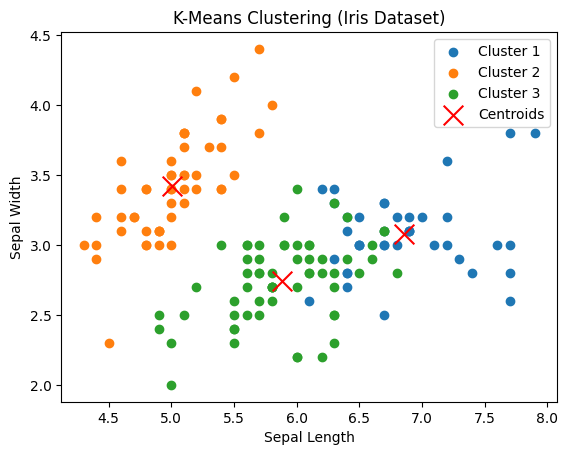

In [9]:
plt.figure()
for i in range(3):
 plt.scatter(
 X.iloc[clusters == i, 0],
 X.iloc[clusters == i, 1],
 label=f'Cluster {i+1}'
 )
centers = kmeans.cluster_centers_
plt.scatter(
 centers[:, 0],
 centers[:, 1],
 c='red',
 marker='x',
 s=200,
 label='Centroids'
)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering (Iris Dataset)")
plt.legend()
plt.show()


In [10]:
print("\nCluster Centroids:")
print(centers)


Cluster Centroids:
[[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.418      1.464      0.244     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]
